In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from datetime import datetime as dt

In [3]:
df=pd.read_csv('/content/drive/MyDrive/DataSets/weatherAUS.csv')
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [4]:
df.shape

(145460, 23)

In [5]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [6]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [8]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


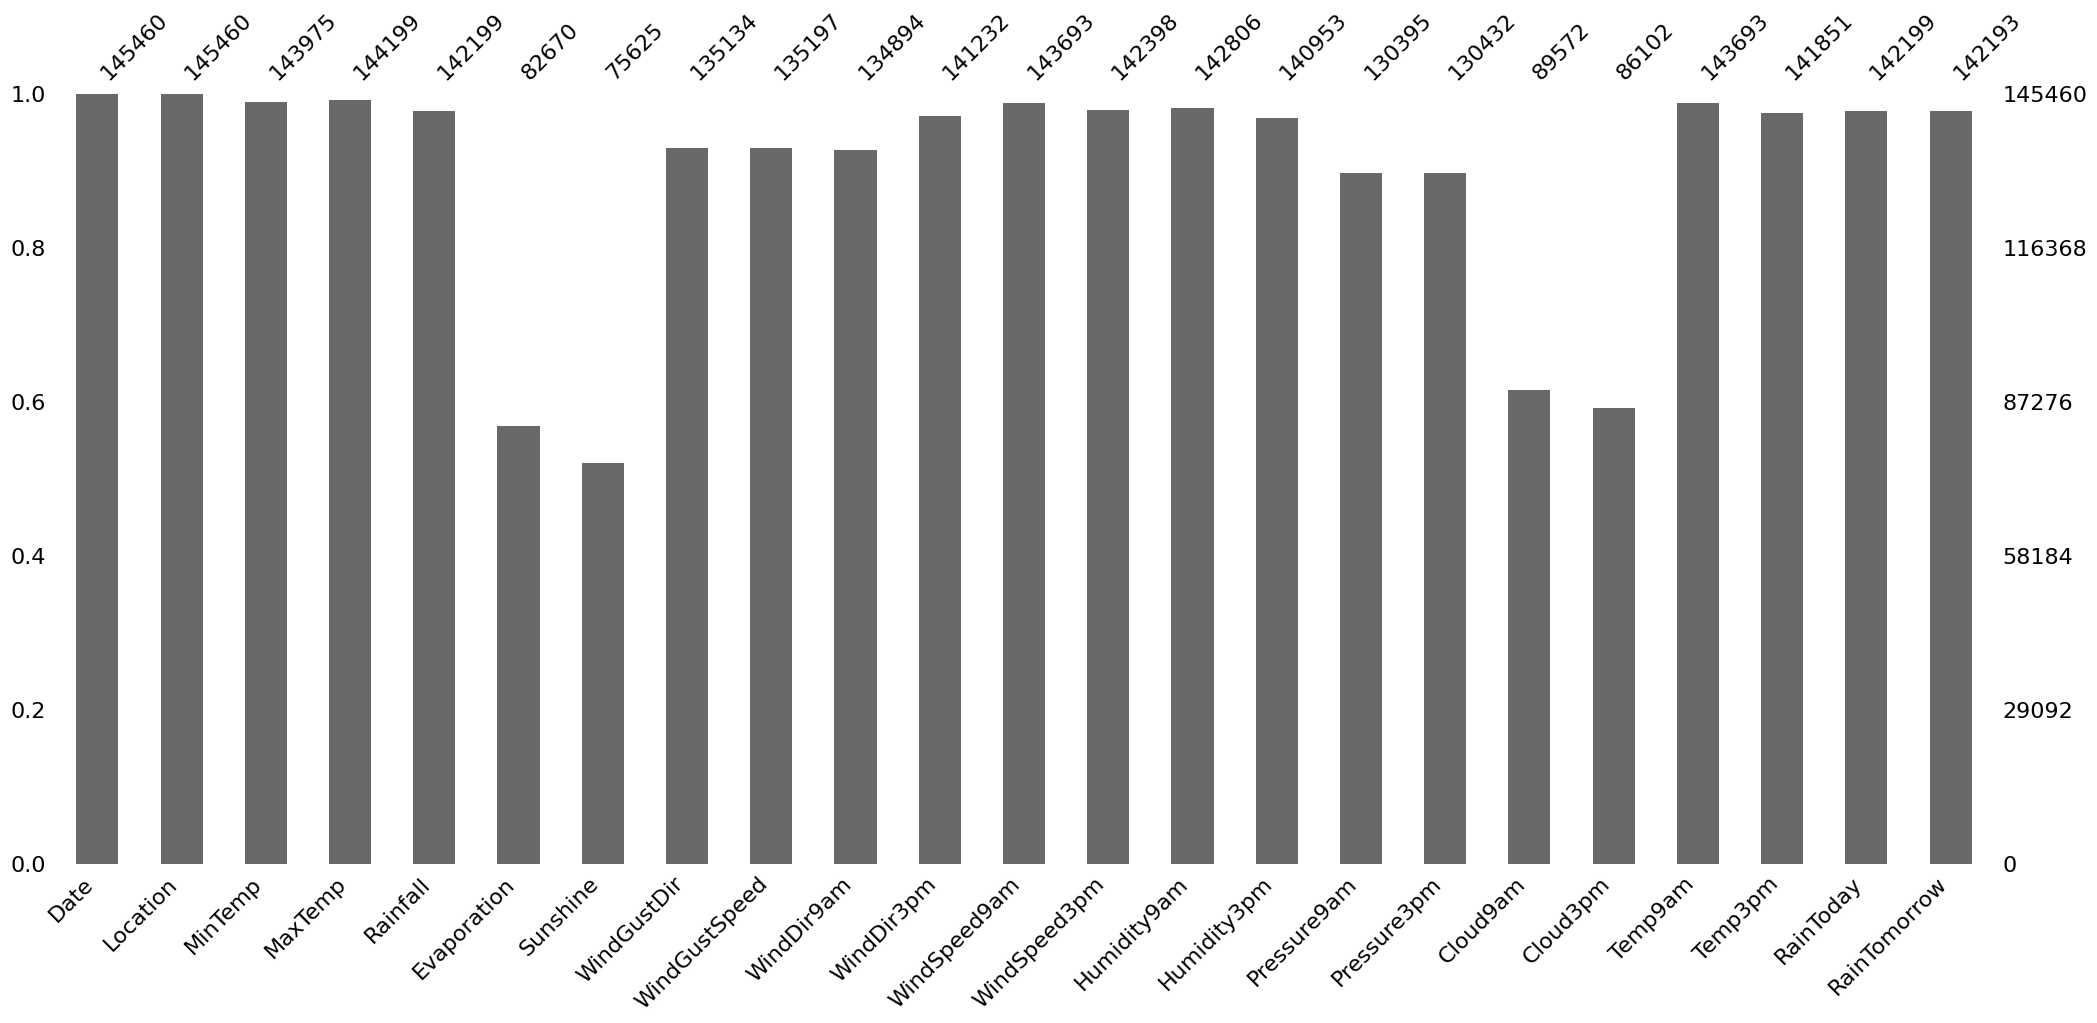

In [9]:
missingno = msno.bar(df)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['RainTomorrow'].value_counts()

,count
RainTomorrow,
No,110316
Yes,31877


In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [13]:
df['years']= df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,years,month,day,dayofweek
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,8.0,NaN,16.9,21.8,No,No,2008,12,1,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,NaN,NaN,17.2,24.3,No,No,2008,12,2,1
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,NaN,2.0,21.0,23.2,No,No,2008,12,3,2
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,NaN,NaN,18.1,26.5,No,No,2008,12,4,3
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,7.0,8.0,17.8,29.7,No,No,2008,12,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,NaN,NaN,10.1,22.4,No,No,2017,6,21,2
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,NaN,NaN,10.9,24.5,No,No,2017,6,22,3
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,NaN,NaN,12.5,26.1,No,No,2017,6,23,4
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,3.0,2.0,15.1,26.0,No,No,2017,6,24,5


In [14]:
le = LabelEncoder()
df['Location_encoded'] = le.fit_transform(df['Location'])
df['WindGustDir_encoded'] = le.fit_transform(df['WindGustDir'])
df['WindDir9am_encoded'] = le.fit_transform(df['WindDir9am'])
df['WindDir3pm_encoded'] = le.fit_transform(df['WindDir3pm'])
df['WindDir3pm_encoded'] = le.fit_transform(df['WindDir3pm'])
df['RainToday_encoded'] = le.fit_transform(df['RainToday'])
df['RainTomorrow_encoded'] = le.fit_transform(df['RainTomorrow'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 33 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Date                  145460 non-null  datetime64[ns]
 1   Location              145460 non-null  object        
 2   MinTemp               143975 non-null  float64       
 3   MaxTemp               144199 non-null  float64       
 4   Rainfall              142199 non-null  float64       
 5   Evaporation           82670 non-null   float64       
 6   Sunshine              75625 non-null   float64       
 7   WindGustDir           135134 non-null  object        
 8   WindGustSpeed         135197 non-null  float64       
 9   WindDir9am            134894 non-null  object        
 10  WindDir3pm            141232 non-null  object        
 11  WindSpeed9am          143693 non-null  float64       
 12  WindSpeed3pm          142398 non-null  float64       
 13 

In [16]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

print(corr_matrix)



                       MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  \
MinTemp               1.000000  0.736555  0.103938     0.466993  0.072586   
MaxTemp               0.736555  1.000000 -0.074992     0.587932  0.470156   
Rainfall              0.103938 -0.074992  1.000000    -0.064351 -0.227549   
Evaporation           0.466993  0.587932 -0.064351     1.000000  0.365602   
Sunshine              0.072586  0.470156 -0.227549     0.365602  1.000000   
WindGustSpeed         0.177415  0.067615  0.133659     0.203021 -0.034750   
WindSpeed9am          0.175064  0.014450  0.087338     0.193084  0.005499   
WindSpeed3pm          0.175173  0.050300  0.057887     0.129400  0.053834   
Humidity9am          -0.232899 -0.504110  0.224405    -0.504092 -0.490819   
Humidity3pm           0.006089 -0.508855  0.255755    -0.390243 -0.629130   
Pressure9am          -0.450970 -0.332061 -0.168154    -0.270362  0.041970   
Pressure3pm          -0.461292 -0.427167 -0.126534    -0.293581 -0.019719   

# **Outliers**

In [17]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols.remove('RainTomorrow_encoded')  # exclude target


for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR


    df = df[df[col].between(lower, upper)]


In [18]:
df.describe()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,years,month,day,dayofweek,Location_encoded,WindGustDir_encoded,WindDir9am_encoded,WindDir3pm_encoded,RainToday_encoded,RainTomorrow_encoded
count,41074,41074.000000,41074.000000,41074.000000,41074.000000,41074.000000,41074.000000,41074.000000,41074.000000,41074.000000,...,41074.000000,41074.000000,41074.000000,41074.00000,41074.000000,41074.000000,41074.000000,41074.000000,41074.0,41074.000000
mean,2012-09-17 09:20:24.774796544,12.943792,24.583201,0.075383,5.442543,8.337902,37.528023,13.855237,18.445440,64.333910,...,2012.225885,6.372450,15.719604,2.94247,25.512977,7.071481,7.025515,7.230267,0.0,0.145396
min,2007-11-01 00:00:00,-5.800000,4.100000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,20.000000,...,2007.000000,1.000000,1.000000,0.00000,3.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,2010-07-12 00:00:00,8.000000,19.500000,0.000000,3.000000,6.200000,30.000000,9.000000,13.000000,54.000000,...,2010.000000,3.000000,8.000000,1.00000,15.000000,3.000000,3.000000,3.000000,0.0,0.000000
50%,2012-07-29 00:00:00,12.800000,24.500000,0.000000,5.200000,9.300000,37.000000,13.000000,19.000000,65.000000,...,2012.000000,6.000000,16.000000,3.00000,27.000000,7.000000,7.000000,8.000000,0.0,0.000000
75%,2014-10-10 00:00:00,17.900000,29.700000,0.000000,7.400000,10.900000,44.000000,19.000000,24.000000,75.000000,...,2014.000000,9.000000,23.000000,5.00000,37.000000,11.000000,11.000000,11.000000,0.0,0.000000
max,2017-06-25 00:00:00,29.700000,43.600000,1.000000,14.400000,14.500000,67.000000,33.000000,39.000000,100.000000,...,2017.000000,12.000000,31.000000,6.00000,48.000000,16.000000,16.000000,16.000000,0.0,2.000000
std,NaN,6.532957,6.543089,0.200447,3.028619,3.518398,10.337341,7.272873,7.565316,16.456225,...,2.451826,3.385844,8.776641,2.00154,12.782585,4.781711,4.833102,4.726735,0.0,0.357715


# **Dealing With Null Values**

In [19]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['month'].apply(month_to_season)

In [20]:
for season in df['Season'].unique():
    median_evap = df.loc[df['Season'] == season, 'Evaporation'].median()

    df.loc[
        (df['Season'] == season) & (df['Evaporation'].isna()),
        'Evaporation'
    ] = median_evap

In [21]:
for season in df['Season'].unique():
    median_sun = df.loc[df['Season'] == season, 'Sunshine'].median()

    df.loc[
        (df['Season'] == season) & (df['Sunshine'].isna()),
        'Sunshine'
    ] = median_sun

In [22]:
for season in df['Season'].unique():
    median_cloud = df.loc[df['Season'] == season, 'Cloud9am'].median()

    df.loc[
        (df['Season'] == season) & (df['Cloud9am'].isna()),
        'Sunshine'
    ] = median_cloud

In [23]:
for season in df['Season'].unique():
    median_cloud = df.loc[df['Season'] == season, 'Cloud3pm'].median()

    df.loc[
        (df['Season'] == season) & (df['Cloud3pm'].isna()),
        'Sunshine'
    ] = median_cloud

# **Feature Engineering**

In [24]:
df['TempRange'] = df['MaxTemp'] - df['MinTemp']
df['HumidityDiff'] = df['Humidity9am'] - df['Humidity3pm']
df['PressureDiff'] = df['Pressure9am'] - df['Pressure3pm']
df['CloudMean'] = (df['Cloud9am'] + df['Cloud3pm']) / 2
df['wind_avg'] = df['WindSpeed9am'] + df['WindSpeed3pm'] / 2
df['TempChange']=df['Temp9am']-df['Temp3pm']

In [25]:
df.dropna(inplace=True)

In [26]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

corr_with_target = corr_matrix['RainTomorrow_encoded'].sort_values(ascending=False)

print(corr_with_target)


RainTomorrow_encoded    1.000000
Humidity3pm             0.358129
Cloud3pm                0.327122
CloudMean               0.318955
TempChange              0.259665
Cloud9am                0.244636
WindGustSpeed           0.152986
Humidity9am             0.152163
Rainfall                0.137648
MinTemp                 0.071489
wind_avg                0.042470
WindSpeed3pm            0.038926
WindSpeed9am            0.034803
WindGustDir_encoded     0.028558
month                   0.017528
Temp9am                 0.008974
WindDir9am_encoded      0.002314
Location_encoded        0.000997
day                    -0.000013
years                  -0.000094
WindDir3pm_encoded     -0.004281
dayofweek              -0.004645
PressureDiff           -0.029261
Evaporation            -0.095459
MaxTemp                -0.096184
Temp3pm                -0.130514
Pressure3pm            -0.173644
Pressure9am            -0.182627
TempRange              -0.240756
HumidityDiff           -0.260270
Sunshine  

In [27]:
df.drop(['Date','MaxTemp','MinTemp','PressureDiff','Cloud9am','Cloud3pm','WindSpeed9am','WindSpeed3pm'],axis = 1,inplace=True)

In [28]:
df.columns

Index(['Location', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir',
       'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm',
       'RainToday', 'RainTomorrow', 'years', 'month', 'day', 'dayofweek',
       'Location_encoded', 'WindGustDir_encoded', 'WindDir9am_encoded',
       'WindDir3pm_encoded', 'RainToday_encoded', 'RainTomorrow_encoded',
       'Season', 'TempRange', 'HumidityDiff', 'CloudMean', 'wind_avg',
       'TempChange'],
      dtype='object')

In [29]:
df.isnull().sum()

,0
Location,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0
WindDir3pm,0
Humidity9am,0
Humidity3pm,0


In [30]:
le = LabelEncoder()
df['Season_encoded'] = le.fit_transform(df['Season'])

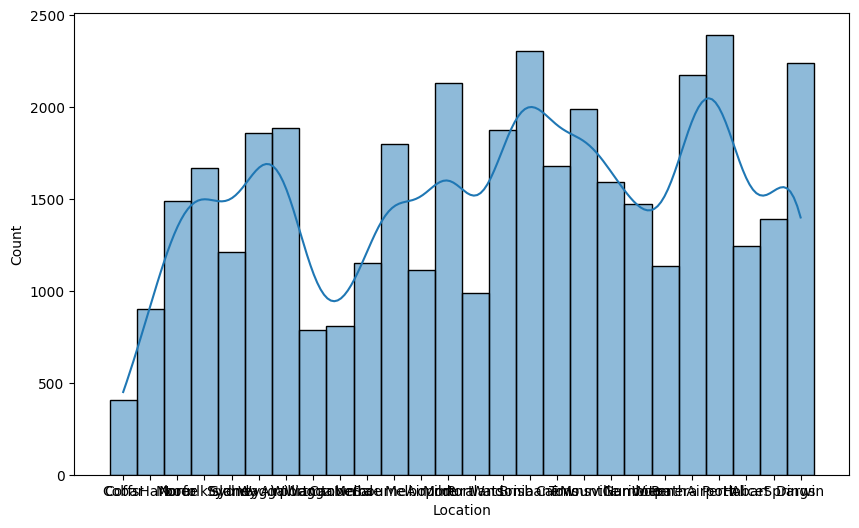

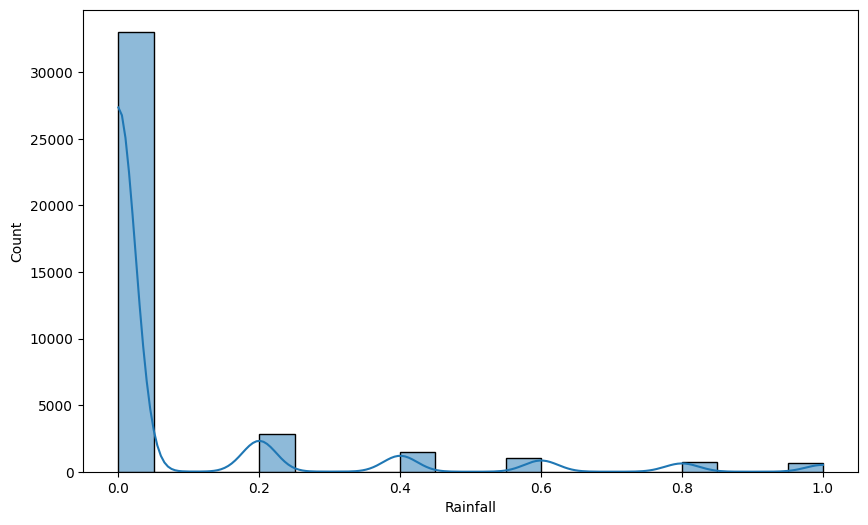

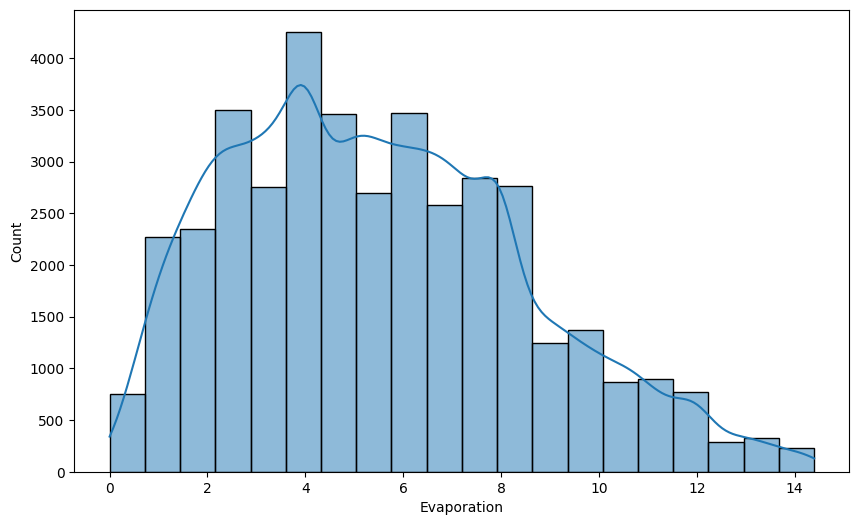

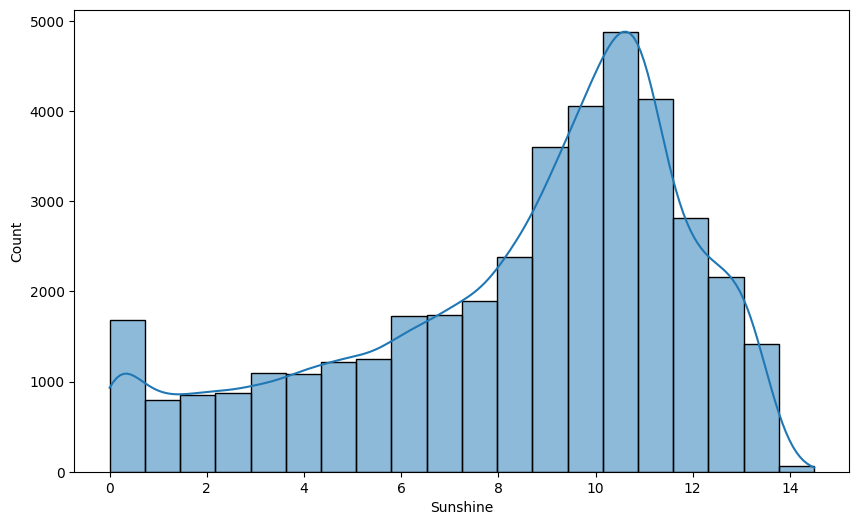

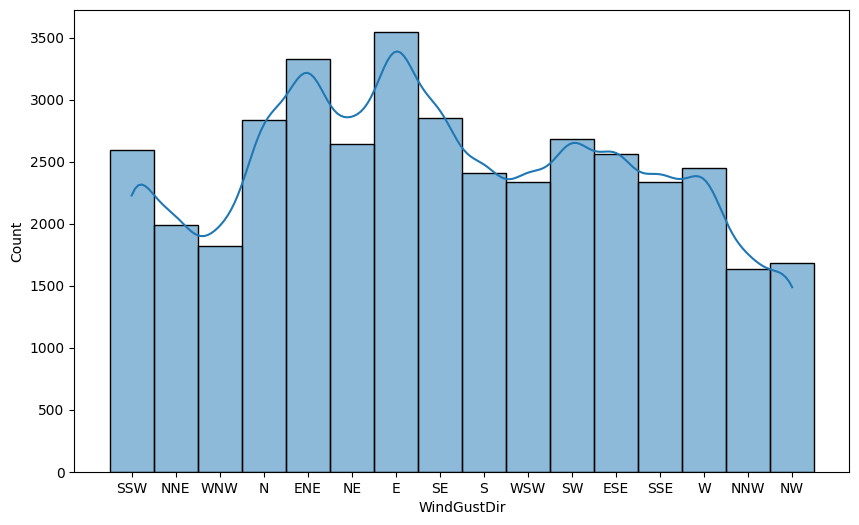

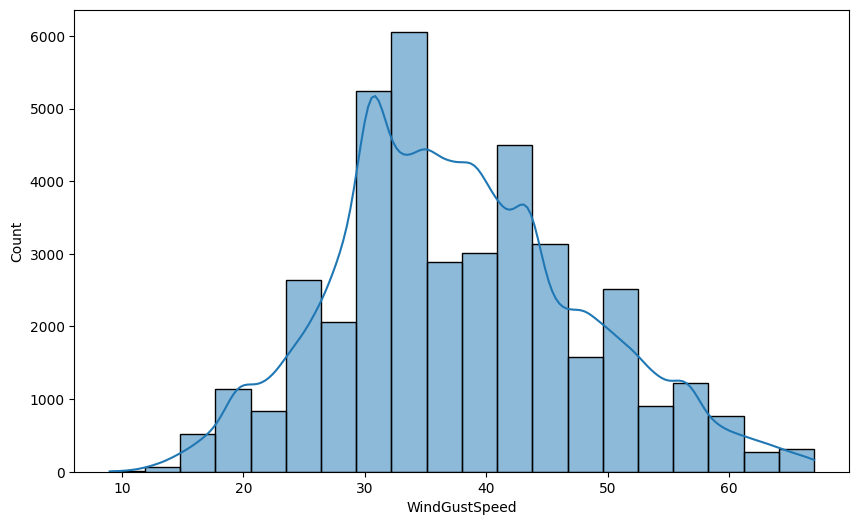

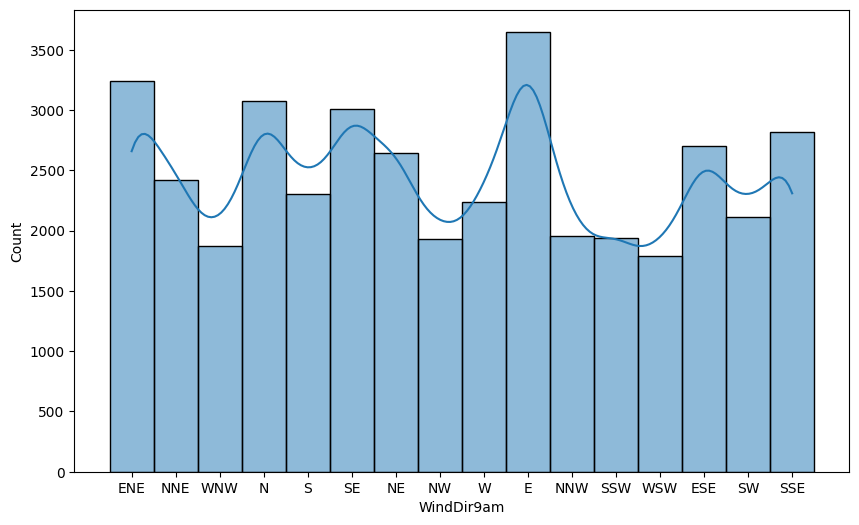

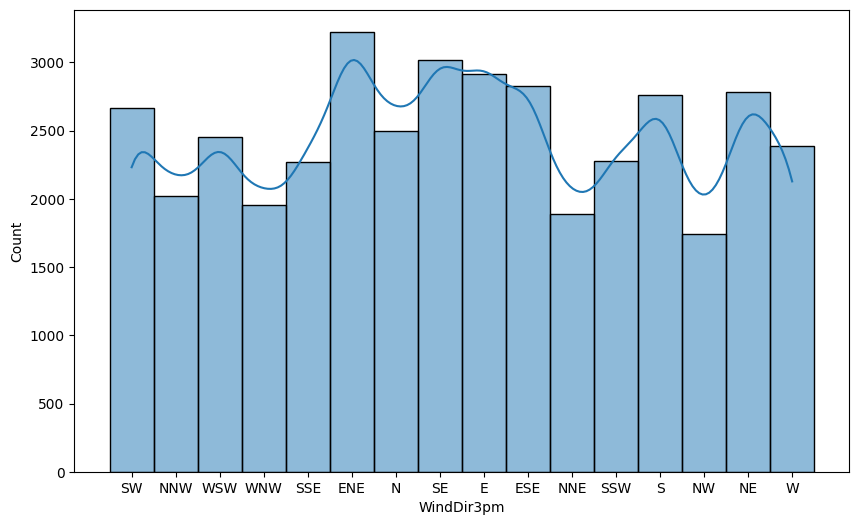

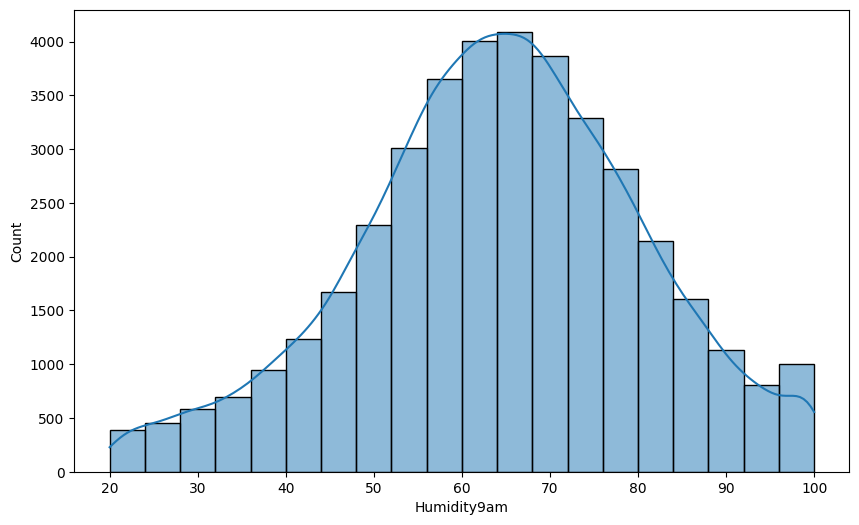

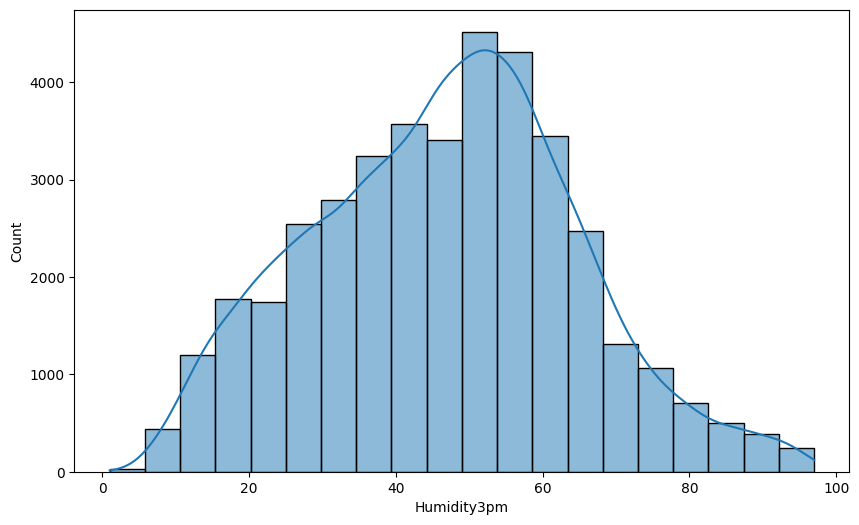

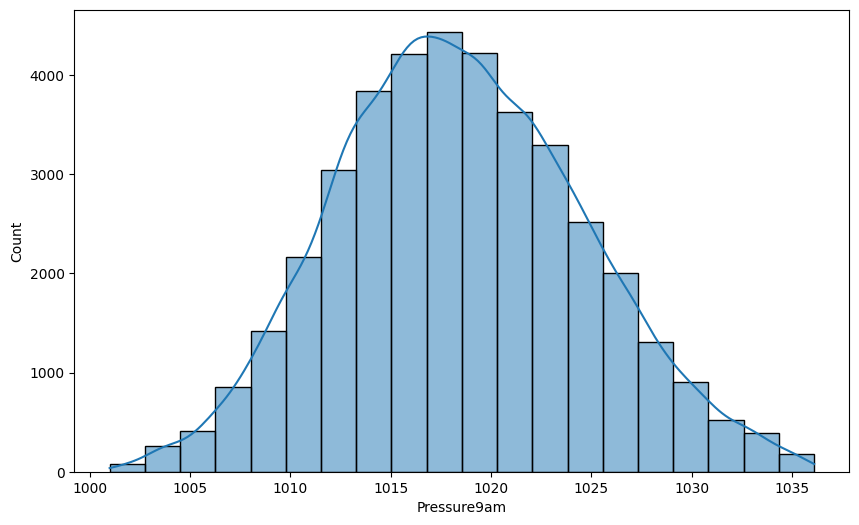

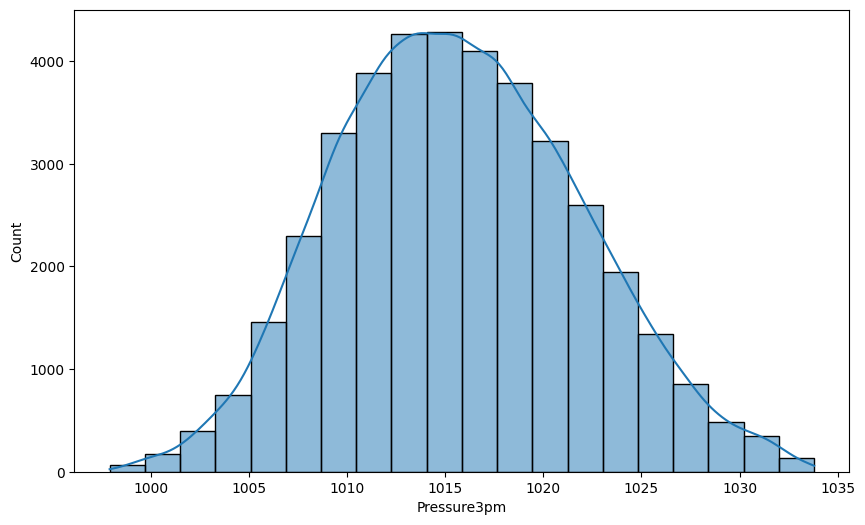

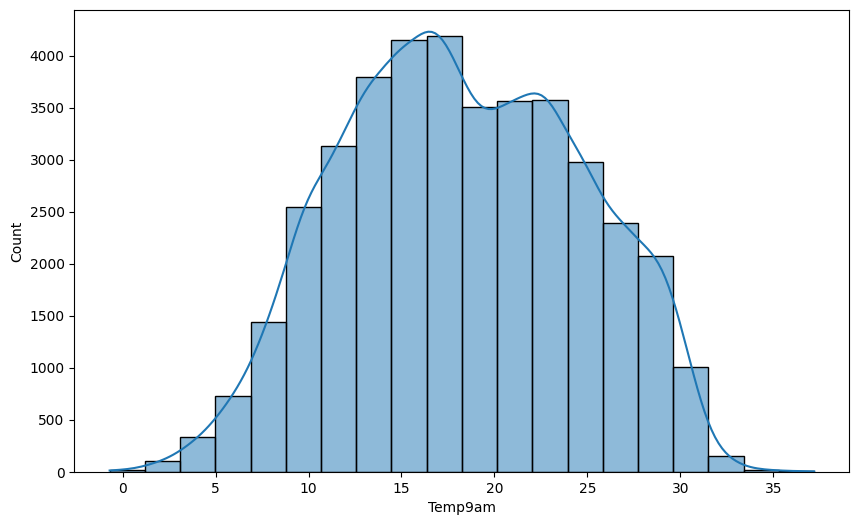

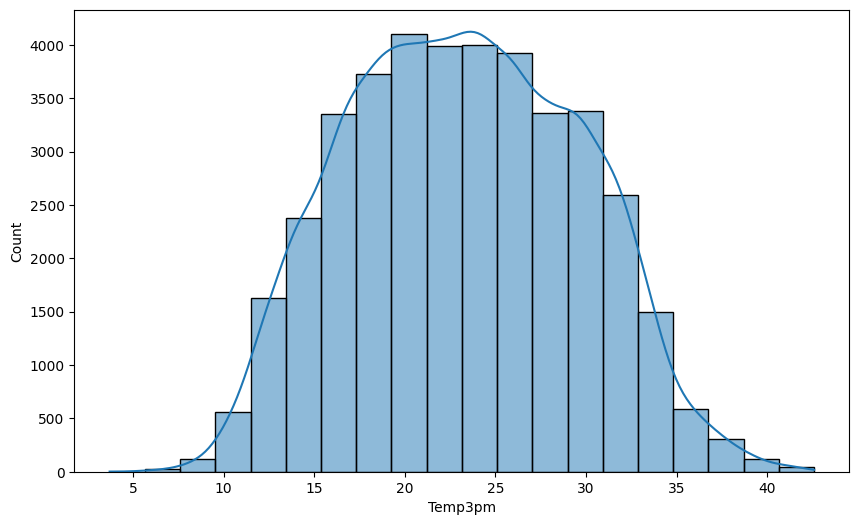

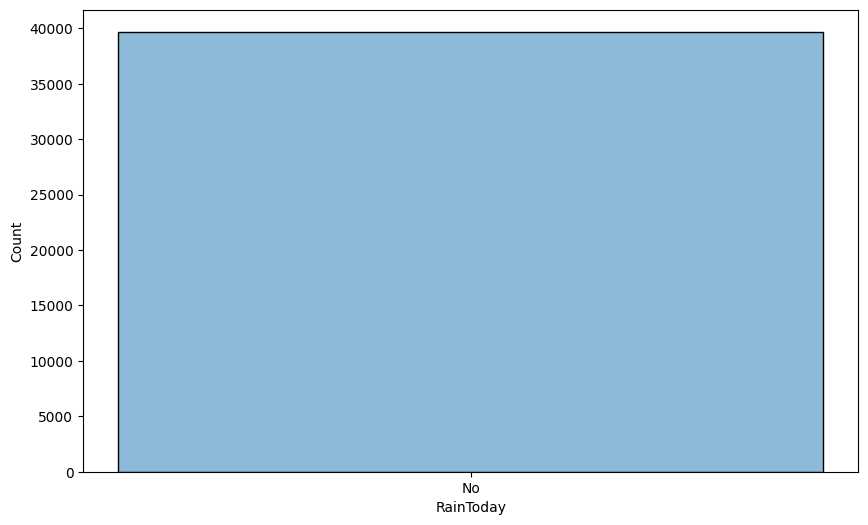

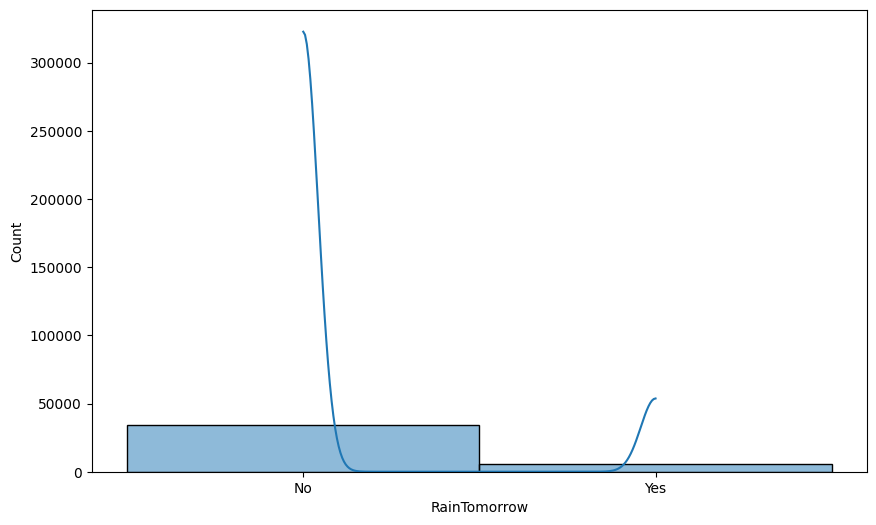

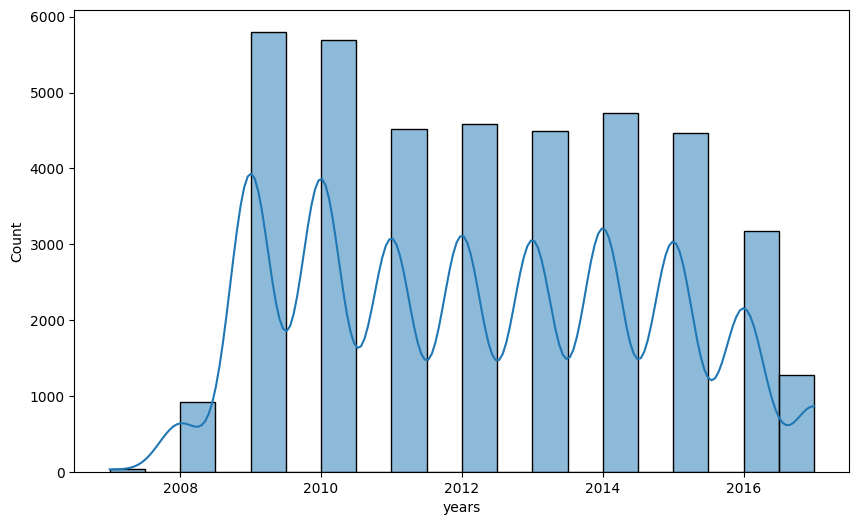

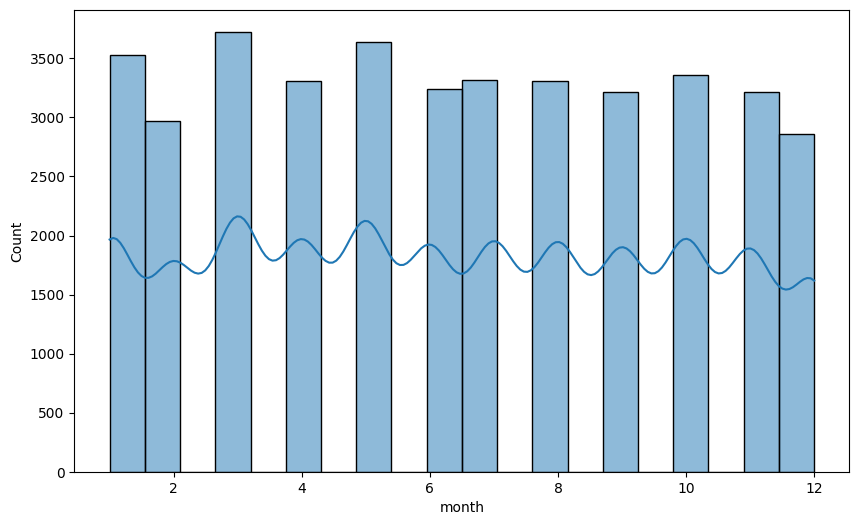

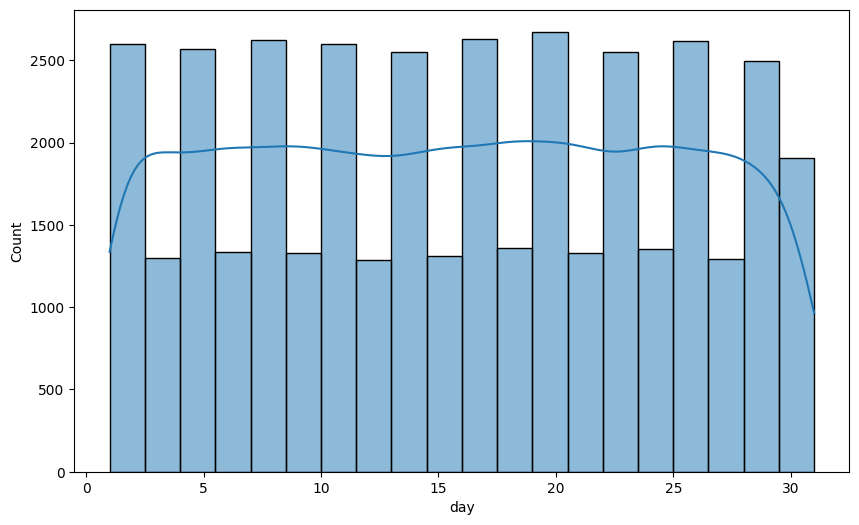

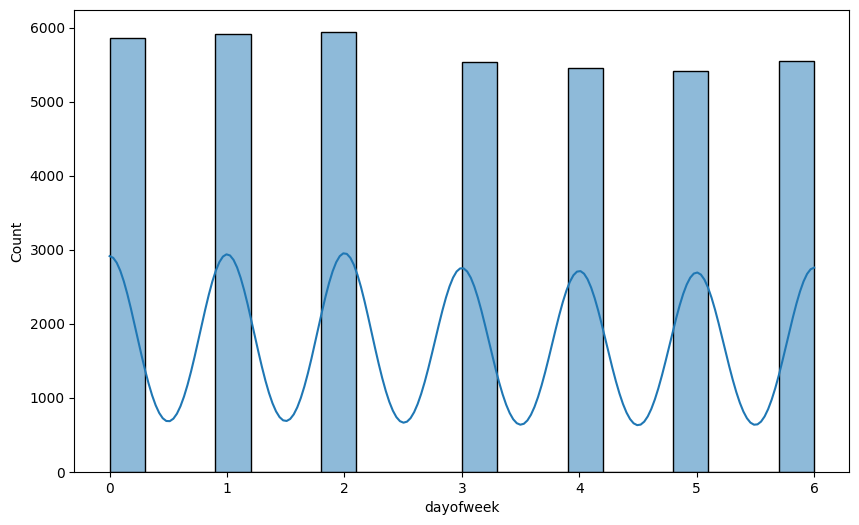

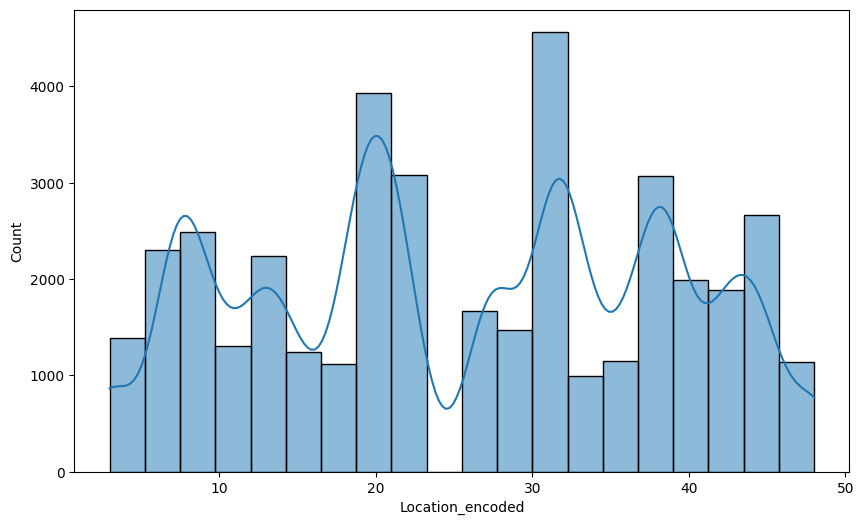

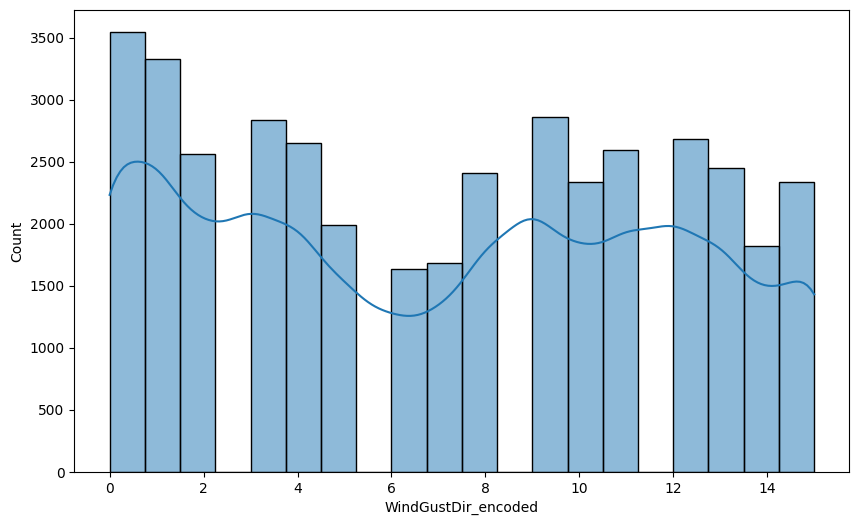

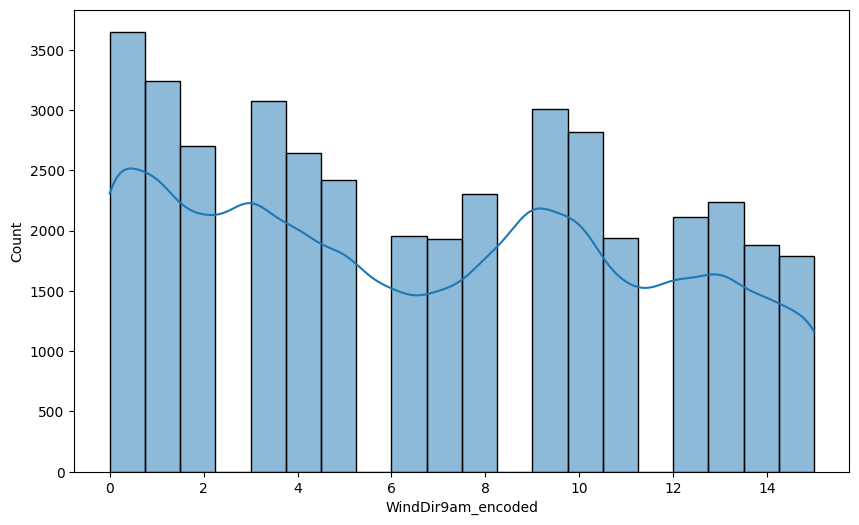

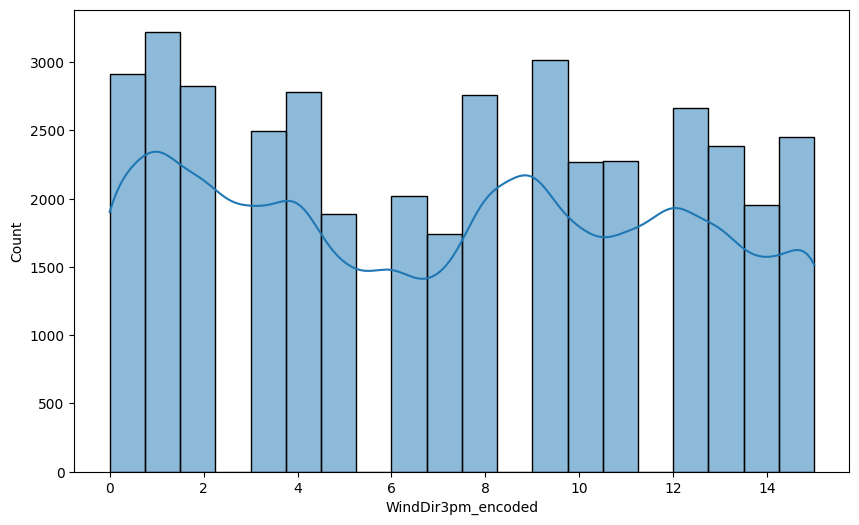

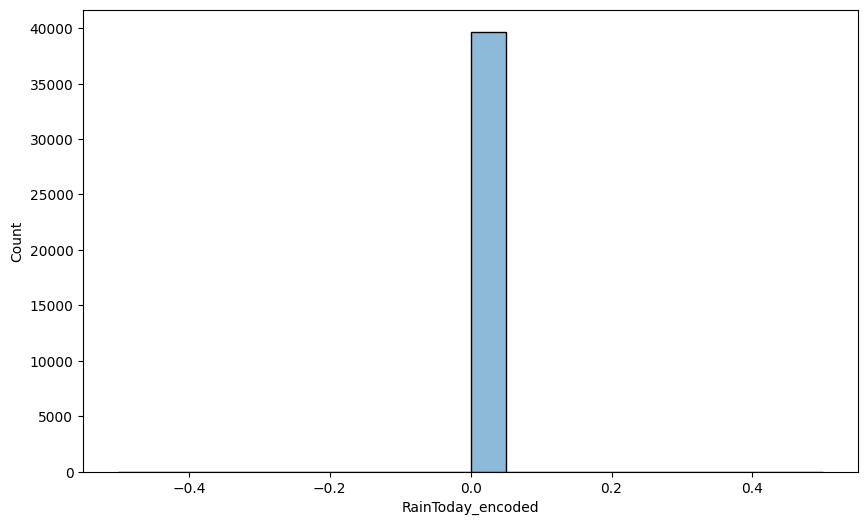

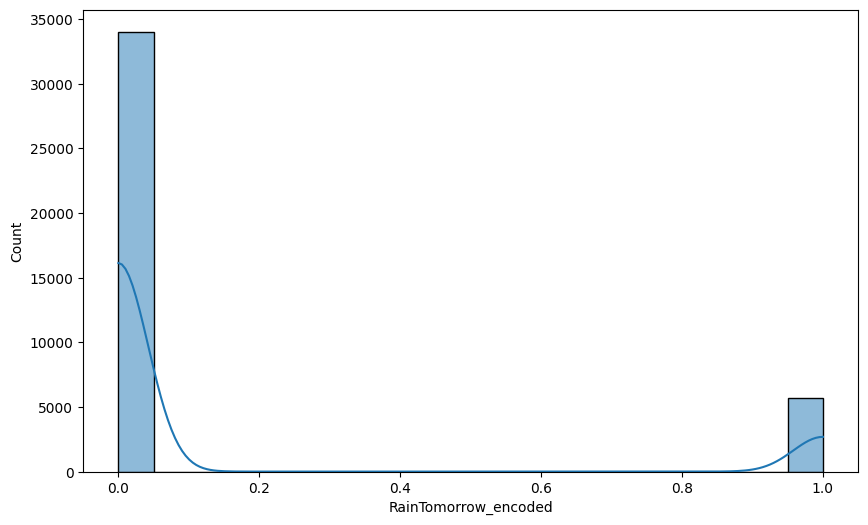

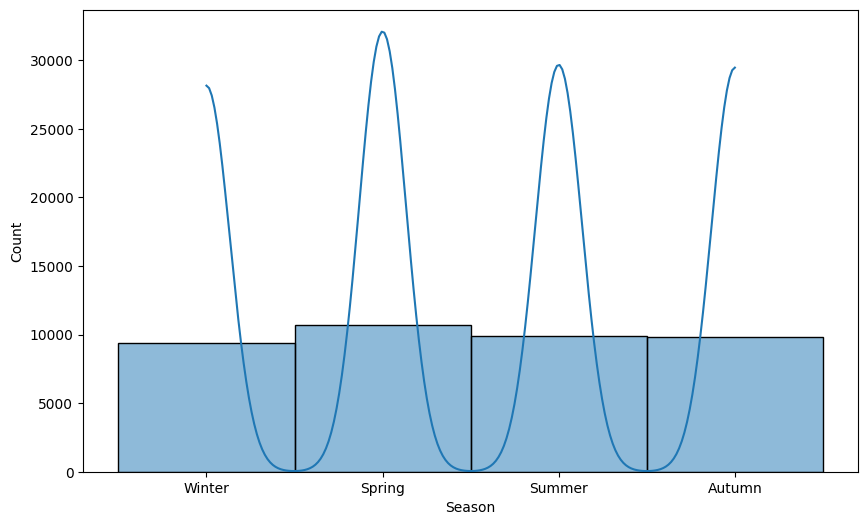

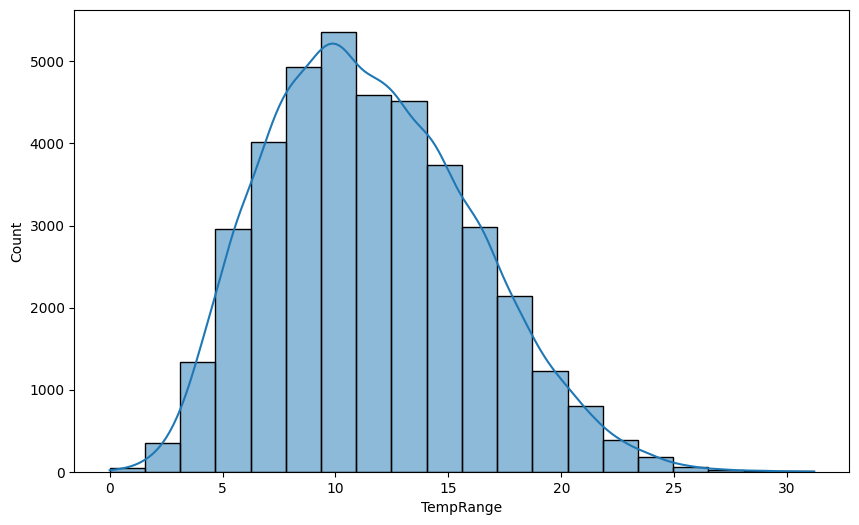

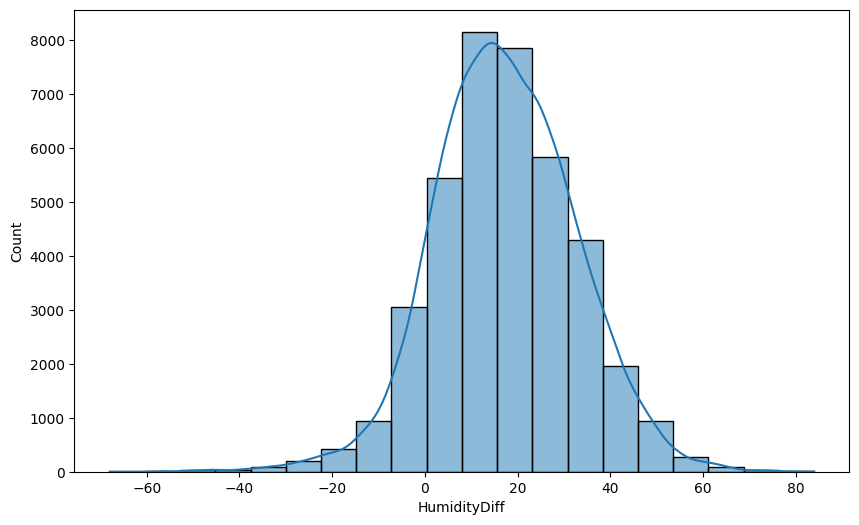

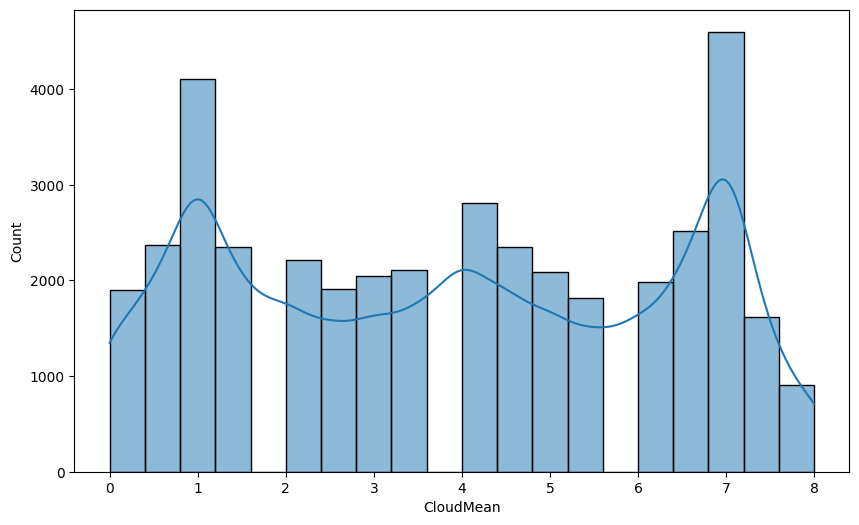

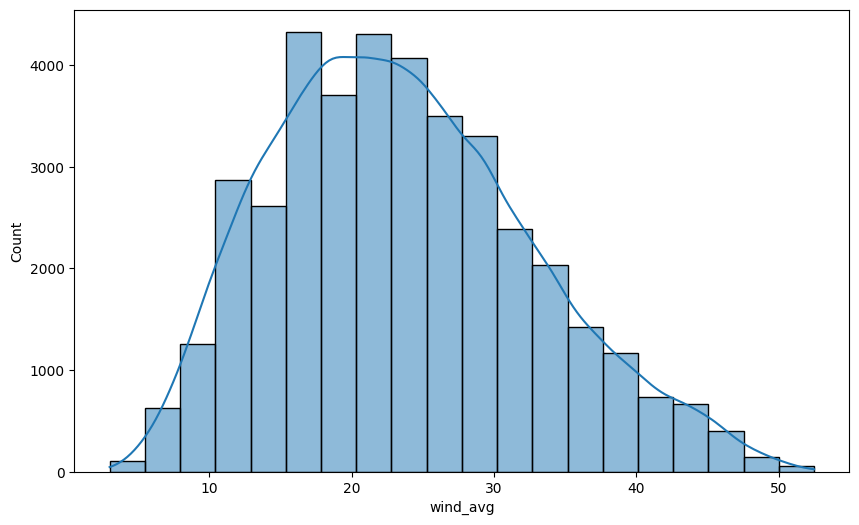

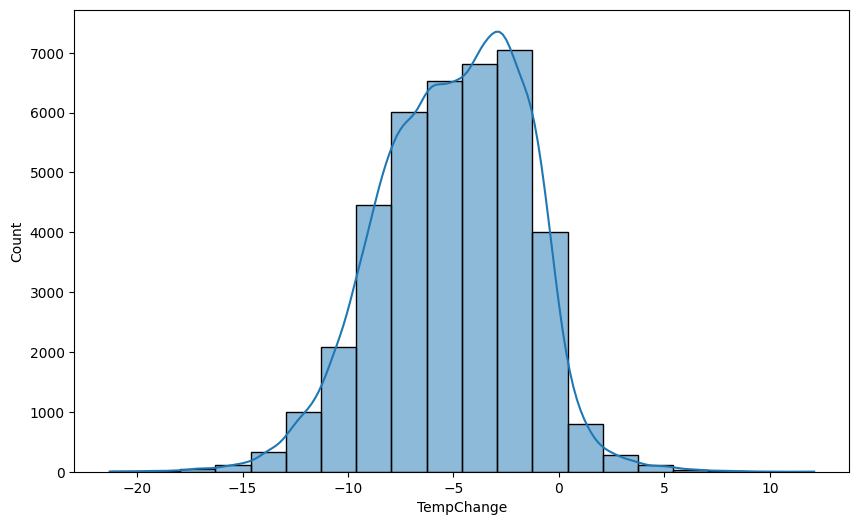

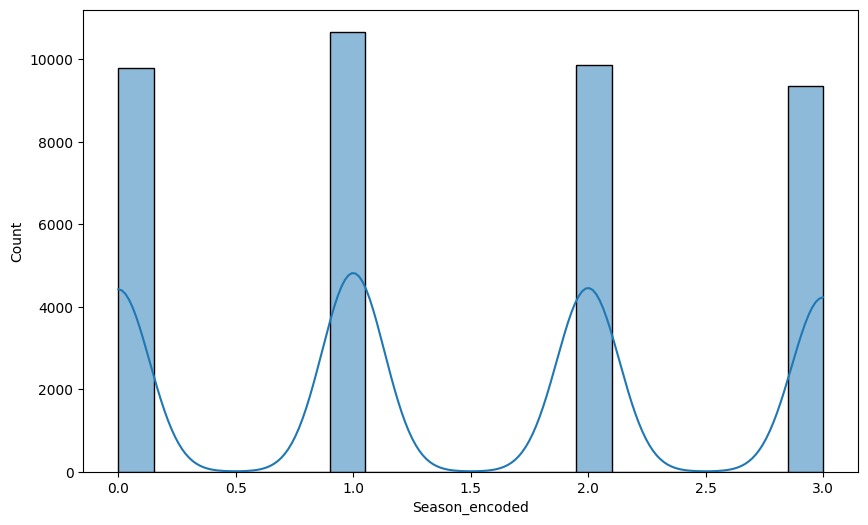

In [31]:
for col in df.columns:
  plt.figure(figsize=(10, 6))
  sns.histplot(df[col], bins=20, kde=True)
  plt.show()

In [32]:
df.to_csv(r"D:\Machine learning\weather_cleaned6.csv", index=False)

In [35]:
df.columns

Index(['Location', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir',
       'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm',
       'RainToday', 'RainTomorrow', 'years', 'month', 'day', 'dayofweek',
       'Location_encoded', 'WindGustDir_encoded', 'WindDir9am_encoded',
       'WindDir3pm_encoded', 'RainToday_encoded', 'RainTomorrow_encoded',
       'Season', 'TempRange', 'HumidityDiff', 'CloudMean', 'wind_avg',
       'TempChange', 'Season_encoded'],
      dtype='object')

In [40]:
X = df[[
    'Rainfall',
    'Evaporation',
    'Sunshine',
    'WindGustSpeed',
    'Humidity9am',
    'Pressure9am',
    'Temp9am',
    'RainToday_encoded',
    'month',
    'dayofweek'
]]
y = df['RainTomorrow_encoded']

In [41]:
train_size = int(0.8 * len(df))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [44]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 88.90428211586901


In [49]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94      6964
           1       0.61      0.28      0.38       976

    accuracy                           0.89      7940
   macro avg       0.76      0.63      0.66      7940
weighted avg       0.87      0.89      0.87      7940



In [50]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[6789  175]
 [ 706  270]]


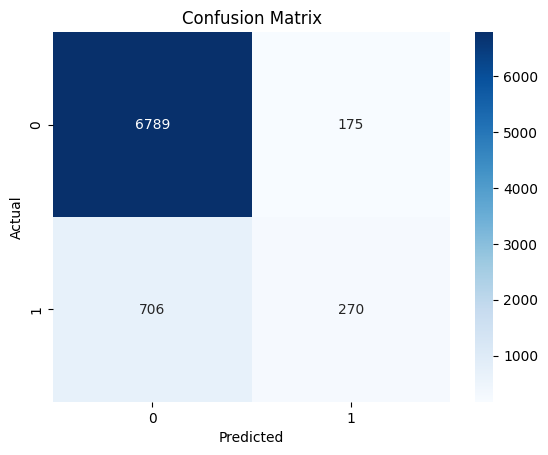

In [51]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()